## Анализ результатов AB-теста

### Импорт библиотек и загрузка датасета

In [20]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats import proportion

In [21]:
import warnings
warnings.simplefilter('ignore')

In [22]:
df = pd.read_csv('D:/Datasets/abtest.csv')
df

,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.0
1,2423,control,0.0
2,9411,control,0.0
3,7311,control,0.0
4,6174,variant,0.0
...,...,...,...
9995,1981,control,0.0
9996,502,variant,0.0
9997,9214,variant,0.0
9998,7741,control,0.0


### Предобработка данных

In [23]:
df.columns = df.columns.str.lower() # - приведем названия столбцов к нижнему регистру

In [24]:
# - добавим столбец с обозначением конвертированных пользователей

def converted(data):
    converted = []
    for index, row in data.iterrows():
        if row['revenue'] == 0:
            conv = 0
            converted.append(conv)
        else:
            conv = 1
            converted.append(conv)
    data['converted'] = converted

converted(df)

In [25]:
# - предположим, что эксперимент проходил в течение года и добавим искусственные метки времени

df['timestamps'] = pd.date_range(start = '1/1/2023', end = '31/12/2023 23:59:59', periods = len(df)) # - метки времени для взаимодействия пользователей с сайтом в 2023 году

df['month'] = df['timestamps'].dt.month # - метка времени для месяца

In [26]:
df

,user_id,variant_name,revenue,converted,timestamps,month
0,737,variant,0.0,0,2023-01-01 00:00:00.000000000,1
1,2423,control,0.0,0,2023-01-01 00:52:33.915291529,1
2,9411,control,0.0,0,2023-01-01 01:45:07.830583058,1
3,7311,control,0.0,0,2023-01-01 02:37:41.745874587,1
4,6174,variant,0.0,0,2023-01-01 03:30:15.661166116,1
...,...,...,...,...,...,...
9995,1981,control,0.0,0,2023-12-31 20:29:43.338833884,12
9996,502,variant,0.0,0,2023-12-31 21:22:17.254125412,12
9997,9214,variant,0.0,0,2023-12-31 22:14:51.169416940,12
9998,7741,control,0.0,0,2023-12-31 23:07:25.084708472,12


- **`user_id`** - уникальный идентификатор пользователя
- **`variant_name`** - старая или новая страница сайта
- **`revenue`** - доход с покупки
- **`converted`** - совершение пользователем покупки (Да/Нет)
- **`timestamps`** - искуственные метки времени, при предположении, что данные в датасете расположены в хронологическом порядке, и эксперимент длился 1 год
- **`month`** - метки времения для каждого месяца

### Визуализация

#### Распределение людей по группам

**Определим соотношение контрольной и тестовой групп**

In [27]:
df.variant_name.value_counts()

variant_name
variant    5016
control    4984
Name: count, dtype: int64

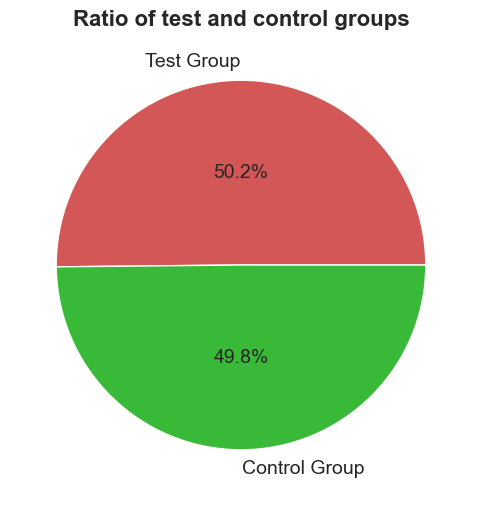

In [28]:
# Круговая диаграмма соотношения тестовой и контрольной групп

test_groups = df['variant_name'].value_counts().tolist()

plt.subplots(figsize = (6,6))

plt.pie(x = test_groups, labels = ['Test Group', 'Control Group'], autopct = '%1.1f%%', textprops={'fontsize': 14}, pctdistance = 0.5,
        colors = ['#D45757', '#38B938'])

plt.title('Ratio of test and control groups', fontsize = 16, fontweight = 'bold')

plt.show()

**Пользователи видели как новую, так и старую версию сайта в одинаковых пропорциях**

#### Средние коэффициенты конверсии

**Рассчитаем коэффициенты конверсии по группам**

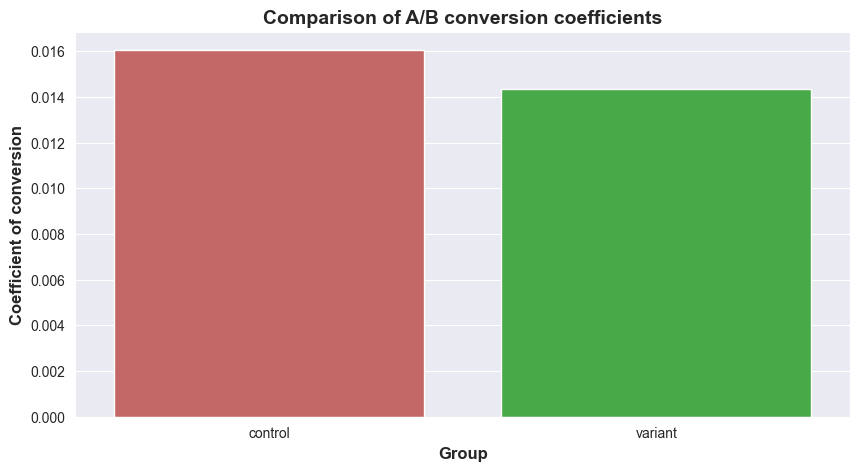

In [29]:
f, ax = plt.subplots(figsize = (10,5))
sns.set_style('darkgrid')

# Столбчатая диаграмма средних коэффициентов конверсии
conv_ratio = df.groupby(by = 'variant_name')['converted'].mean()
sns.barplot(x = conv_ratio.index, y = conv_ratio.values, palette = ['#D45757', '#38B938'])
plt.title('Comparison of A/B conversion coefficients', fontsize = 14, fontweight = 'bold')
plt.xlabel('Group', fontsize = 12, fontweight = 'bold')
plt.ylabel('Coefficient of conversion', fontsize = 12, fontweight = 'bold')

plt.show()

**В контрольной группе средний коэффициент конверсии незначительно выше `(на 0.2%)`, чем в тестовой группе**

#### Бутстрап-анализ

**Проведем бутстрап-анализ для оценки различий в средних коэффициентах конверсии между группами**

In [30]:
# Определим функцию
def bootstrap (data, samples = 10000):
  means = []
  for i in range (samples):
    boot_sample = np.random.choice(data, size = len(data), replace = True)
    means.append(boot_sample.mean())
  return means

# Рассчитаем средние значения для каждой группы
bootmeans_control = bootstrap(df[df['variant_name'] == 'control']['converted'])
bootmeans_variant = bootstrap(df[df['variant_name'] == 'variant']['converted'])

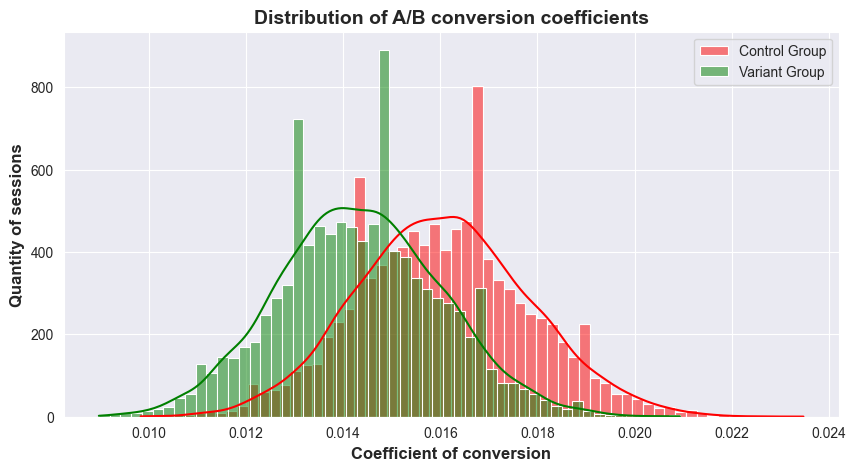

In [31]:
f, ax = plt.subplots(figsize = (10,5))

# Гистограмма распределения средних коэффициентов конверсии
sns.histplot(bootmeans_control, color = 'r', kde = True, label = 'Control Group')
sns.histplot(bootmeans_variant, color = 'g', kde = True, label = 'Variant Group')
plt.title('Distribution of A/B conversion coefficients', fontsize = 14, fontweight = 'bold')
plt.xlabel('Coefficient of conversion', fontsize = 12, fontweight = 'bold')
plt.ylabel('Quantity of sessions', fontsize = 12, fontweight = 'bold')
plt.legend()

plt.show()

**Судя по проведенному анализу, средние значения коэффициентов конверсии в группах различаются незначительно.**

#### Коэффициенты конверсии в динамике

**Оценим поведение пользователей в динамике**

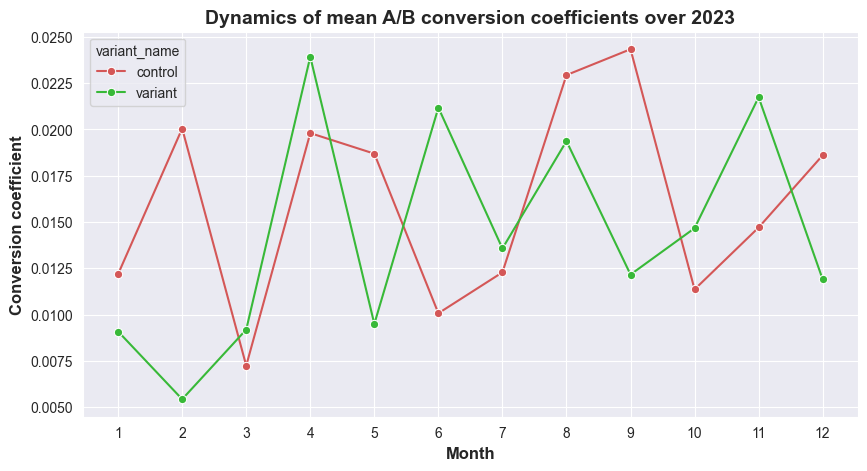

In [32]:
f, ax = plt.subplots(figsize = (10,5))
monthly_meanconv = df.groupby(by = ['month', 'variant_name'])['converted'].mean().unstack()

# Динамика по месяцам для 2023 года
sns.lineplot(data = monthly_meanconv, markers = ['o', 'o'], palette = ['#D45757', '#38B938'], dashes = False)
plt.xticks(range(1, 13, 1))
plt.title('Dynamics of mean A/B conversion coefficients over 2023', fontsize = 14, fontweight = 'bold')
plt.xlabel('Month', fontsize = 12, fontweight = 'bold')
plt.ylabel('Conversion coefficient', fontsize = 12, fontweight = 'bold')

plt.show()

Рассматривая коэффициенты конверсии **в динамике**, можно сделать вывод, что **средние коэффициенты конверсии на протяжентии всего эксперимента**, как для **`тестовой`**, так и для **`контрольной`** группы, **колеблятся** в интервале от **`0.5%`** до **`2.5%`**

### Проверка статистической значимости

#### ХИ-2 тест

**Проведем тест Хи-квадрат для оценки значимости различий в коэффициентах конверсии между двумя группами**

In [33]:
contingency_table = pd.crosstab(df['variant_name'], df['converted']) # - таблица для проведения ХИ-2 теста
display(contingency_table)

converted,0,1
variant_name,,
control,4904,80
variant,4944,72


In [34]:
chi2, p_value, dof, exp = scipy.stats.chi2_contingency(contingency_table) # - проведем тест и оценим p-значение
print('ХИ2 =', chi2)
print('\np-value =', p_value)

ХИ2 = 0.37441985868631433

p-value = 0.5406048684924643


**Высокое значение `p-value` указывает на `отсутствие статистической значимости` между коэффициентами конверсий в двух группах. Таким образом, `разделение` пользователей `на` данные `группы` является `необоснованным` с точки зрения статистики**

#### Z-тест

**Проведем двухпропорционный z-тест**

In [35]:
n_control = df.loc[df['variant_name'] == 'control']['converted'].sum() # - число конверсий в группе Control
n1 = df.loc[df['variant_name'] == 'control'].shape[0] # - объем контрольной группы

n_variant = df.loc[df['variant_name'] == 'variant']['converted'].sum() # - число конверсий в группе Variant
n2 = df.loc[df['variant_name'] == 'control'].shape[0] # - объем тестовой группы

In [36]:
count = np.array([n_control, n_variant]) # - объем совершенных целевых действий
nobs = np.array([n1, n2]) # - объем наблюдений

p_value = proportion.proportions_ztest(count, nobs)[1]

In [37]:
print(p_value)
print('\np_value < 0.05:', p_value < 0.05)

0.5131824469965021

p_value < 0.05: False


**`p-value`** **превышает пороговое значение**, из чего следует вывод о том, что мы **принимаем нулевую гипотезу H0** об **`отсутствии статистический значимости` внесенных на сайт изменений**. 

### Анализ доверительного интервала

**Определим коэффициент доверия `(t)`** для расчета предельной ошибки при **уровне значимости `5%`**

In [38]:
t = np.abs(scipy.stats.t.ppf((0.05) / 2, df.shape[0] - 1))
t

1.960201263621358

**Рассчитаем количество и долю конверсий в общем количестве наблюдений**

In [39]:
num = df.converted.sum()
p = num/df.shape[0]
print('Количество покупок равно:', num)
print('\nДоля конверсии равна:', '%.3f' % p)

Количество покупок равно: 152

Доля конверсии равна: 0.015


**Рассчитаем предельную ошибку и доверительный интервал**

In [40]:
se_ratio = np.sqrt((p * (1-p) / df.shape[0])) # - стандартная предельная ошибка

lowerratio = p - se_ratio * t # - нижняя граница доверительного интервала
upperratio = p + se_ratio * t # - верхняя граница доверительного интервала

print(f'\nДоверительный интервал для конверсии: {round(lowerratio, 3)} < {round(p, 3)} < {round(upperratio, 3)}')


Доверительный интервал для конверсии: 0.013 < 0.015 < 0.018


#### Визуализация доверительного интервала

**Визуализируем границы `доверительного интервала` на построенном ранее графике результатов `бутстрап`-анализа**

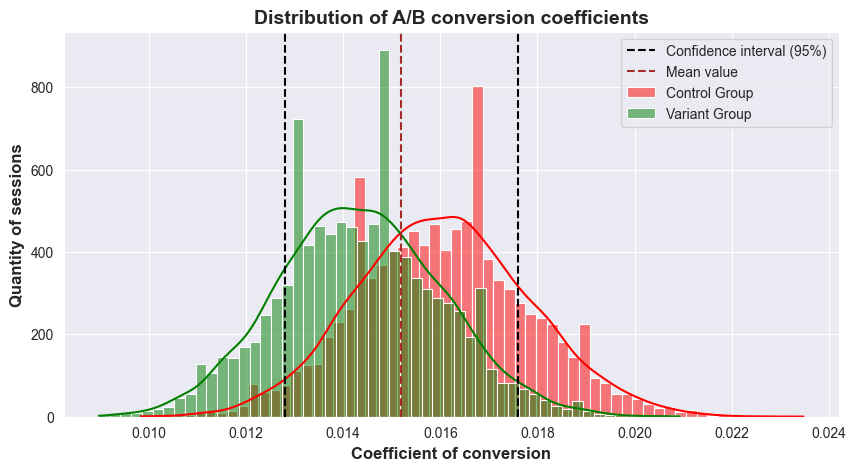

In [41]:
f, ax = plt.subplots(figsize = (10,5))

# Гистограмма распределения средних коэффициентов конверсии
sns.histplot(bootmeans_control, color = 'r', kde = True, label = 'Control Group')
sns.histplot(bootmeans_variant, color = 'g', kde = True, label = 'Variant Group')
plt.title('Distribution of A/B conversion coefficients', fontsize = 14, fontweight = 'bold')
plt.xlabel('Coefficient of conversion', fontsize = 12, fontweight = 'bold')
plt.ylabel('Quantity of sessions', fontsize = 12, fontweight = 'bold')

plt.axvline(x = lowerratio, color = 'k', linestyle = '--', label = 'Confidence interval (95%)')
plt.axvline(x = upperratio, color = 'k', linestyle = '--')
plt.axvline(x = p, color = 'brown', linestyle = '--', label = 'Mean value')
plt.legend()

plt.show()

Как можно заметить, **средние значения конверсий в обеих группах** умещаются в построенный **`доверительный интервал`**. С **`95%`** вероятностью мы можем утверждать, что **среднее значение конверсии** будет находиться **в интервале от `1.3%` до `1.8%`**

### Вывод

В ходе анализа проведенного **`A/B тестирования`** были **`рассчитаны`** и **`оценены`** в динамике **`средние коэффициенты конверсии`** на сайте. Также был **`проведен бутстрап-анализ`** для оценки различий средних коэффициентов конверсии **между `контрольной` и `тестовой` группами**. **В ходе проверки статистической значимости** полученных результатов, были **`проведены ХИ-2 тест и двухпропорционный Z-тест`**. Дополнительно был **`построен`** и **`визуализирован`** **`доверительный интервал` для средней конверсии на сайте**.

**Результаты проделанной работы позволяют сделать вывод об `отсутствии статистически значимых различий` между средними значениями коэффициентов конверсии в двух группах**. Таким образом, **`изменения`**, внесенные на сайт Интернет-магазина **`не повлекли` за собой `увеличение продаж`**. Также, учитывая **`низкие показатели конверсии и выручки с продаж`, Интернет-магазин работает `неэффективно`**. Причин тому может быть большое множество: от **`непривлекательного дизайна` и `структуры` веб-сайта** до **`слабой маркетинговой кампании`** и **`продажи непопулярного товара`**.